### 1. Import bibliotek i ustawienie ścieżek

In [1]:
import os, cv2, glob, json, math
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

MODEL_PATH = 'saved_models/image_model_final.h5'
MAP_PATH = 'saved_models/image_emotion_map.json'
DATA_DIR = 'processed_data/data_test'

### 2. Ładowanie modelu i mapy emocji

In [2]:
model = tf.keras.models.load_model(MODEL_PATH)
with open(MAP_PATH, 'r') as f:
    emotion_map = {int(k): v for k, v in json.load(f).items()}
print("✅ Gotowe")

✅ Gotowe


### 3. Predykcja i wizualizacja wyników

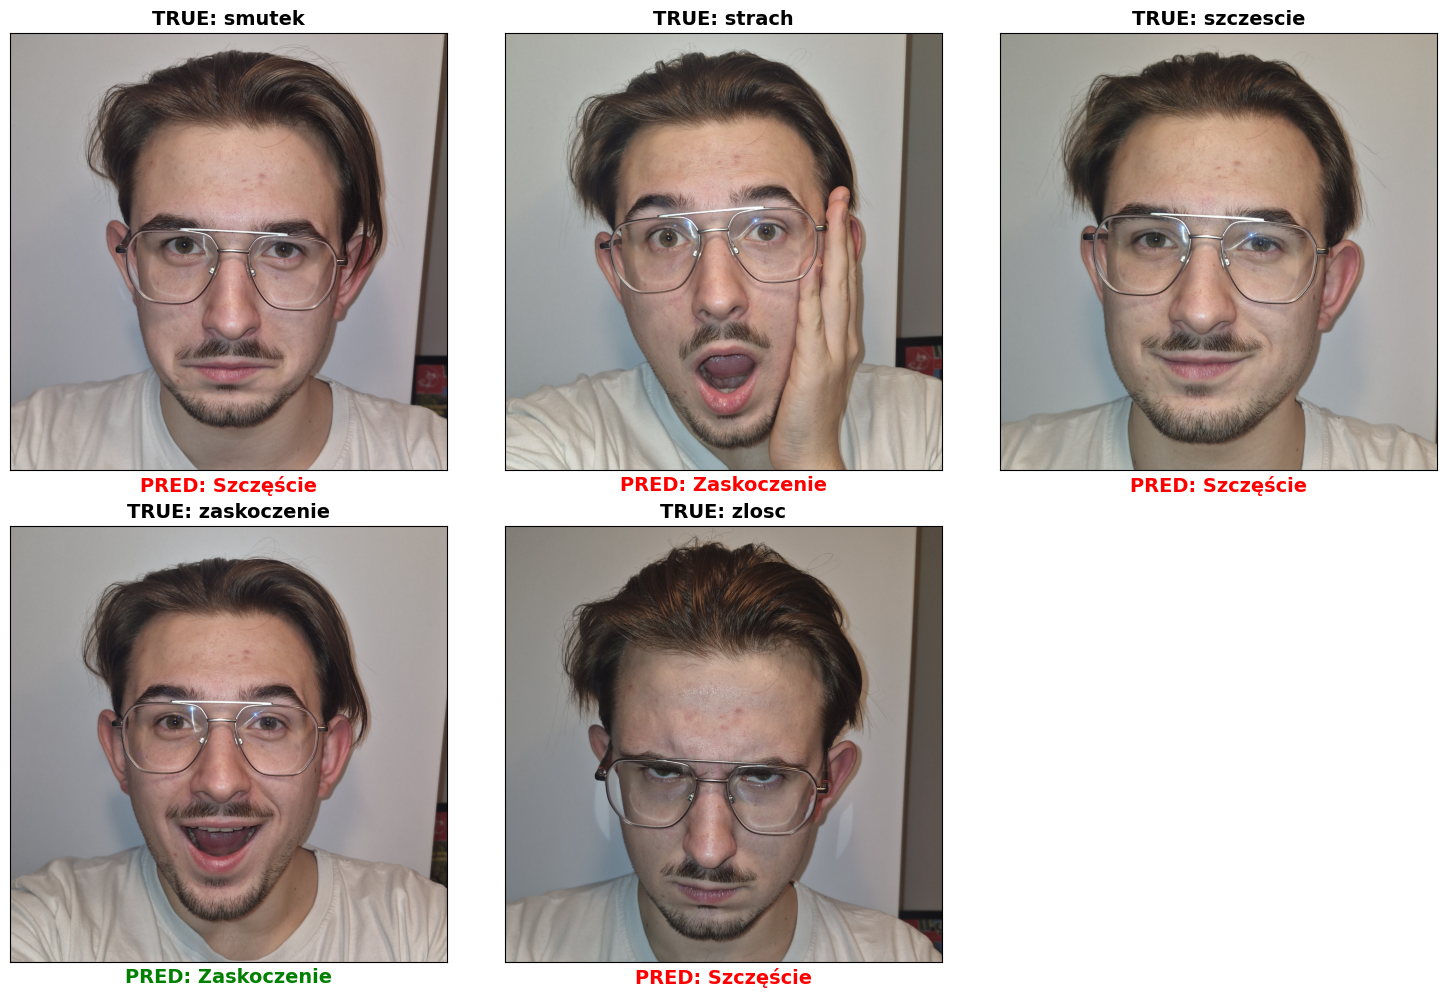

In [3]:
files = [f for f in glob.glob(os.path.join(DATA_DIR, '*.*')) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

if not files:
    print("Brak zdjęć")
else:
    plt.figure(figsize=(15, 5 * math.ceil(len(files)/3)))
    for i, path in enumerate(files):
        img = cv2.imread(path)
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img, (224, 224))
        pred = model.predict(np.expand_dims(img_resized/255.0, axis=0), verbose=0)
        pred_label = emotion_map.get(np.argmax(pred), "?")
        true_label = os.path.splitext(os.path.basename(path))[0].split('_')[-1]
        
        plt.subplot(math.ceil(len(files)/3), 3, i+1)
        plt.imshow(img)
        plt.title(f"TRUE: {true_label}", fontsize=14, fontweight='bold')
        plt.xlabel(f"PRED: {pred_label}", color='green' if true_label.lower() in pred_label.lower() else 'red', fontsize=14, fontweight='bold')
        plt.xticks([]); plt.yticks([])
    plt.tight_layout()
    plt.show()

### 4. Macierz błędów - AffectNet (zbiór testowy treningowy)

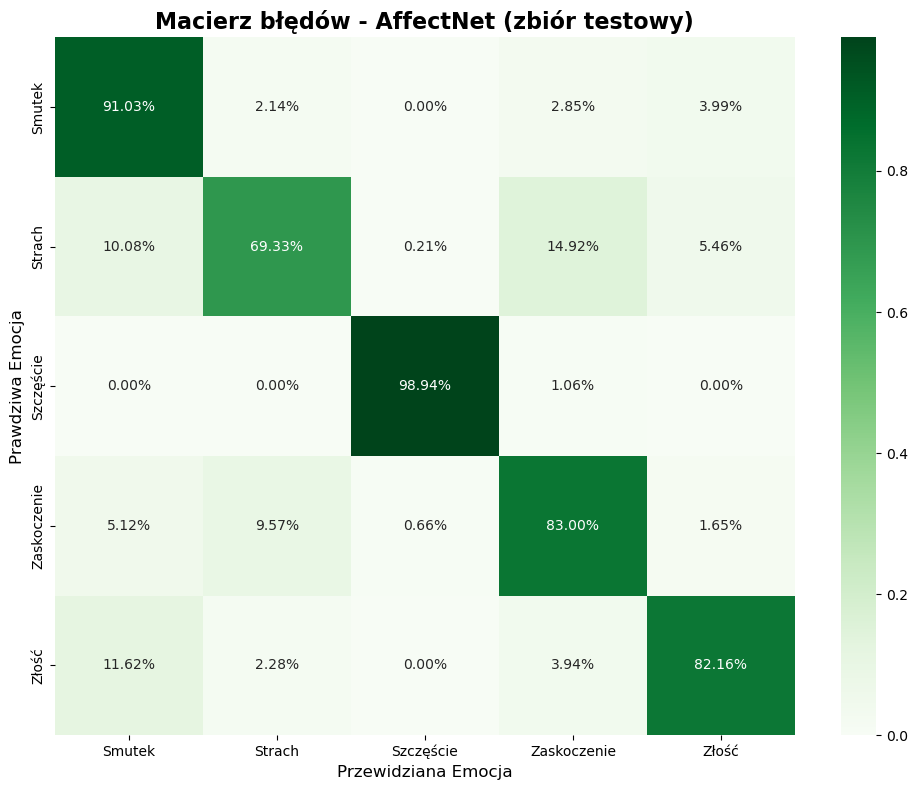


RAPORT:
Smutek         : Precision=82.56%, Recall=91.03%, F1=86.59%
Strach         : Precision=79.71%, Recall=69.33%, F1=74.16%
Szczęście      : Precision=99.34%, Recall=98.94%, F1=99.14%
Zaskoczenie    : Precision=81.00%, Recall=83.00%, F1=81.99%
Złość          : Precision=86.09%, Recall=82.16%, F1=84.08%

ACCURACY       : 86.57%


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
from tensorflow.keras.utils import to_categorical

test_img = pd.read_csv('processed_data/test_images.csv')
test_img = test_img[test_img['emotion'] != 'neutral'].reset_index(drop=True)
emotions_list = sorted([v for v in emotion_map.values()])
emotion_to_id = {v: k for k, v in emotion_map.items()}

try:
    import kagglehub
    BASE_PATH = kagglehub.dataset_download("mstjebashazida/affectnet")
except:
    BASE_PATH = 'C:\\Users\\kubal\\.cache\\kagglehub\\datasets\\mstjebashazida\\affectnet\\versions\\1'

test_img['full_path'] = test_img['path'].apply(lambda x: os.path.normpath(os.path.join(BASE_PATH, x)))
test_img = test_img[test_img['full_path'].apply(os.path.exists)].reset_index(drop=True)

if len(test_img) == 0:
    print("❌ Brak plików")
else:
    labels_array = to_categorical(test_img['emotion'].map(emotion_to_id).values, num_classes=len(emotion_map)).astype(np.float32)
    
    def load_img(path_bytes):
        try:
            path = path_bytes.numpy().decode('utf-8')
            with open(path, "rb") as f:
                img = cv2.imdecode(np.asarray(bytearray(f.read()), dtype=np.uint8), cv2.IMREAD_COLOR)
            if img is None: return np.zeros((224, 224, 3), dtype=np.float32)
            return cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), (224, 224)).astype(np.float32) / 255.0
        except:
            return np.zeros((224, 224, 3), dtype=np.float32)
    
    def wrapper(path, label):
        img = tf.py_function(load_img, [path], tf.float32)
        img.set_shape([224, 224, 3])
        return img, label
    
    dataset = tf.data.Dataset.from_tensor_slices((test_img['full_path'].values, labels_array))
    dataset = dataset.map(wrapper, num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)
    
    y_pred, y_true = [], []
    for images, labels in dataset:
        y_pred.extend(model.predict(images, verbose=0).argmax(axis=1))
        y_true.extend(labels.numpy().argmax(axis=1))
    
    labels_ids = [emotion_to_id[e] for e in emotions_list]
    cm = confusion_matrix(y_true, y_pred, labels=labels_ids)
    cm_normalized = np.nan_to_num(cm.astype('float') / cm.sum(axis=1)[:, np.newaxis])
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens', xticklabels=emotions_list, yticklabels=emotions_list)
    plt.title('Macierz błędów - AffectNet (zbiór testowy)', fontsize=16, fontweight='bold')
    plt.ylabel('Prawdziwa Emocja', fontsize=12)
    plt.xlabel('Przewidziana Emocja', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    report = classification_report(y_true, y_pred, labels=labels_ids, target_names=emotions_list, output_dict=True)
    print("\nRAPORT:")
    for emotion in emotions_list:
        if emotion in report:
            m = report[emotion]
            print(f"{emotion:15}: Precision={m['precision']:.2%}, Recall={m['recall']:.2%}, F1={m['f1-score']:.2%}")
    if 'accuracy' in report:
        print(f"\n{'ACCURACY':15}: {report['accuracy']:.2%}")

### 5. Macierz błędów - Własny zbiór testowy (data_test)

C:\Users\kubal\AppData\Local\Temp\ipykernel_25608\1243844176.py:20: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


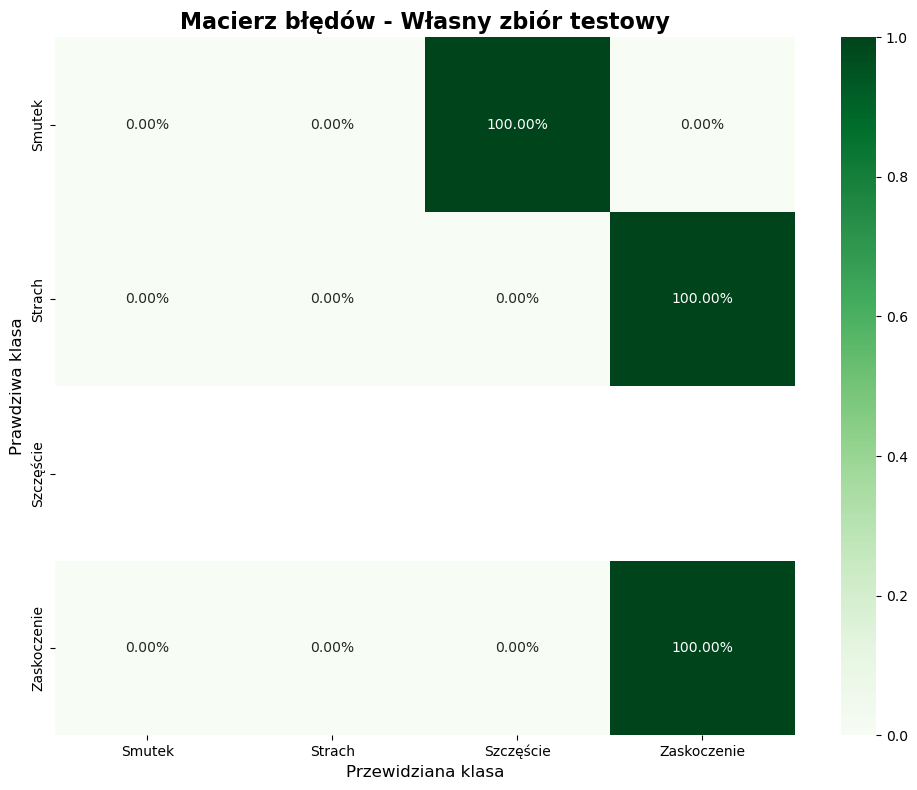


RAPORT:
              precision    recall  f1-score   support

      Smutek       0.00      0.00      0.00         1
      Strach       0.00      0.00      0.00         1
   Szczęście       0.00      0.00      0.00         0
 Zaskoczenie       0.50      1.00      0.67         1

    accuracy                           0.33         3
   macro avg       0.12      0.25      0.17         3
weighted avg       0.17      0.33      0.22         3


Dokładność: 33.33%


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklea

In [5]:
files = [f for f in glob.glob(os.path.join(DATA_DIR, '*.*')) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

if not files:
    print("Brak zdjęć")
else:
    y_true, y_pred = [], []
    for path in files:
        img = cv2.imread(path)
        if img is None: continue
        img = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), (224, 224))
        pred_idx = np.argmax(model.predict(np.expand_dims(img/255.0, axis=0), verbose=0))
        true_label = os.path.splitext(os.path.basename(path))[0].split('_')[-1]
        true_idx = next((idx for idx, emotion in emotion_map.items() if true_label.lower() in emotion.lower() or emotion.lower() in true_label.lower()), None)
        if true_idx is not None:
            y_true.append(true_idx)
            y_pred.append(pred_idx)
    
    if len(y_true) > 0:
        cm = confusion_matrix(y_true, y_pred)
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        labels = [emotion_map[i] for i in sorted(set(y_true + y_pred))]
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens', xticklabels=labels, yticklabels=labels)
        plt.title('Macierz błędów - Własny zbiór testowy', fontsize=16, fontweight='bold')
        plt.ylabel('Prawdziwa klasa', fontsize=12)
        plt.xlabel('Przewidziana klasa', fontsize=12)
        plt.tight_layout()
        plt.show()
        
        print("\nRAPORT:")
        print(classification_report(y_true, y_pred, target_names=labels))
        print(f"\nDokładność: {sum([1 for t, p in zip(y_true, y_pred) if t == p]) / len(y_true):.2%}")
    else:
        print("Brak danych")